In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
import xgboost as xgb


import gc
from sklearn.metrics import confusion_matrix, r2_score,mean_absolute_error, mean_squared_error,explained_variance_score,accuracy_score,f1_score,roc_auc_score, auc, roc_curve,classification_report
from sklearn import preprocessing
from feature_engine.encoding import OrdinalEncoder

from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier, plot_importance

from feature_engine.selection import DropCorrelatedFeatures, SmartCorrelatedSelection

In [2]:
# function with different metrics to evaluate train model
def evaluating_the_train_model(y_train, y_predict_train):
    
    print('Classification report train set')
    print(classification_report(y_train, y_predict_train))
    print()
    
    print('r2 squared error train set:',r2_score(y_train, y_predict_train))
    print('explained variance score train set:',explained_variance_score(y_train, y_predict_train))
    print('mean absolute error train set:',mean_absolute_error(y_train, y_predict_train))
    print('mean squared error  train set:',mean_squared_error(y_train, y_predict_train))
    print('roc-auc score: {}'.format(roc_auc_score(y_train, y_predict_train)))
    print()
    
    print('Confusion matrix train set')
    cm = confusion_matrix(y_train, y_predict_train)
    sns.heatmap(cm, annot = True)
    plt.show()
    
    
# function with different metrics to evaluate test model    
def evaluating_the_test_model(y_test, y_predict_test):
    
    print('Classification report test set')
    print(classification_report(y_test, y_predict_test))
    print()
    
    print('r2 squared error test set:',r2_score(y_test, y_predict_test))
    print('explained variance score test set:',explained_variance_score(y_test, y_predict_test))
    print('mean absolute error test set:',mean_absolute_error(y_test, y_predict_test))
    print('mean squared error test set:',mean_squared_error(y_test, y_predict_test))
    print('roc-auc score: {}'.format(roc_auc_score(y_test, y_predict_test)))
    print()
    
    print('Confusion matrix test set')
    cm = confusion_matrix(y_test, y_predict_test)
    sns.heatmap(cm, annot = True)
    plt.show()
    

#predicting model and evaluating it with metrics
def metrics_of_predicted_models(X_train, X_test, y_train, y_test,classifier,name_of_the_model):
    
    y_predict_train = classifier.predict(X_train)
    y_predict_test = classifier.predict(X_test)
    print(name_of_the_model)
    print('Train set')
    evaluating_the_train_model(y_train, y_predict_train)
    pred = classifier.predict_proba(X_train)
    train_roc_auc_proba = roc_auc_score(y_train,pred[:,1])
    print(name_of_the_model+ ' train roc-auc with predict_proba: {}'.format(train_roc_auc_proba))
    print()
    
    print('Test set')
    evaluating_the_test_model(y_test, y_predict_test)
    pred = classifier.predict_proba(X_test)
    test_roc_auc_proba = roc_auc_score(y_test,pred[:,1])
    print(name_of_the_model+ ' test roc-auc with predict_proba: {}'.format(test_roc_auc_proba))
    print()
    
    train_roc_auc[name_of_the_model] = train_roc_auc_proba
    test_roc_auc[name_of_the_model] = test_roc_auc_proba

#looking for the best parameters with grid search
def grid_search_best_parameters(classifier, parameters, X_train, y_train,name_of_the_model):
     
    grid_search = GridSearchCV(
            estimator = classifier, 
            param_grid = parameters,
            scoring = 'accuracy',
            cv = 10,
            n_jobs = -1)

    grid_search.fit(X_train, y_train)

    best_accuracy = grid_search.best_score_
    best_parameters = grid_search.best_params_

    print("Best accuracy: {:2f} %".format(best_accuracy * 100))
    print("Best parameters: ", best_parameters)
    print()

    model = grid_search.best_estimator_
    
    best_accuracy_with_best_parameters[name_of_the_model] = best_accuracy * 100


In [3]:
#models results
train_roc_auc = dict()
test_roc_auc = dict()
best_accuracy_with_best_parameters = dict()

In [5]:
frames = list()
results = pd.read_csv('../milling_tool/input/train.csv')

In [7]:
for i in range(1,19):
    exp = '0'+str(i) if i<10 else str(i)
    
    frame = pd.read_csv('../milling_tool/input/experiment_{}.csv'.format(exp))
                        
    row = results[results['No'] == i]
    frame['target'] = 1 if row.iloc[0]['tool_condition'] == 'worn' else 0
    
    frames.append(frame)

In [8]:
df = pd.concat(frames, ignore_index= True)

df

,X1_ActualPosition,X1_ActualVelocity,X1_ActualAcceleration,X1_CommandPosition,X1_CommandVelocity,X1_CommandAcceleration,X1_CurrentFeedback,X1_DCBusVoltage,X1_OutputCurrent,X1_OutputVoltage,...,S1_DCBusVoltage,S1_OutputCurrent,S1_OutputVoltage,S1_OutputPower,S1_SystemInertia,M1_CURRENT_PROGRAM_NUMBER,M1_sequence_number,M1_CURRENT_FEEDRATE,Machining_Process,target
0,198.0,0.00,0.00,198.0,0.00,0.000000,0.18,0.0207,329.0,2.77,...,2.740000e-19,329.0,0.0,6.960000e-07,12.0,1.0,0.0,50.0,Starting,0
1,198.0,-10.80,-350.00,198.0,-13.60,-358.000000,-10.90,0.1860,328.0,23.30,...,2.740000e-19,328.0,0.0,-5.270000e-07,12.0,1.0,4.0,50.0,Prep,0
2,196.0,-17.80,-6.25,196.0,-17.90,-0.000095,-8.59,0.1400,328.0,30.60,...,2.740000e-19,328.0,0.0,9.100000e-07,12.0,1.0,7.0,50.0,Prep,0
3,194.0,-18.00,0.00,194.0,-17.90,-0.000095,-6.11,0.1300,327.0,30.30,...,2.740000e-19,328.0,0.0,1.070000e-06,12.0,1.0,7.0,50.0,Prep,0
4,193.0,-17.90,-18.80,192.0,-17.90,0.000095,-5.70,0.1140,328.0,30.50,...,2.740000e-19,328.0,0.0,1.960000e-06,12.0,1.0,7.0,50.0,Prep,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25281,144.0,-2.30,100.00,144.0,-2.57,0.977000,-5.05,0.0732,327.0,9.56,...,8.260000e-01,323.0,118.0,1.580000e-01,12.0,1.0,57.0,3.0,End,1
25282,144.0,-2.47,25.00,144.0,-2.46,1.080000,-5.62,0.0996,327.0,10.30,...,9.710000e-01,320.0,119.0,1.870000e-01,12.0,1.0,57.0,3.0,End,1
25283,143.0,-2.20,81.20,143.0,-2.35,1.170000,-4.42,0.0539,327.0,7.79,...,9.500000e-01,322.0,119.0,1.820000e-01,12.0,1.0,57.0,3.0,End,1
25284,143.0,-2.05,68.70,143.0,-2.23,1.260000,-5.83,0.0809,327.0,8.32,...,9.590000e-01,322.0,118.0,1.820000e-01,12.0,1.0,57.0,3.0,End,1


<Axes: xlabel='target', ylabel='count'>

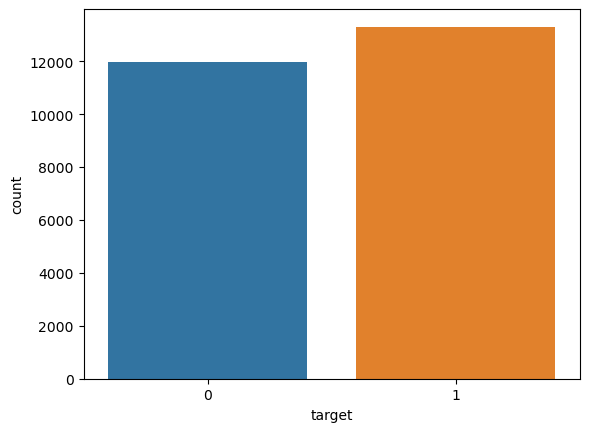

In [9]:
sns.countplot(x = df['target'], label = 'Count') #looks like almost balanced dataset

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25286 entries, 0 to 25285
Data columns (total 49 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   X1_ActualPosition          25286 non-null  float64
 1   X1_ActualVelocity          25286 non-null  float64
 2   X1_ActualAcceleration      25286 non-null  float64
 3   X1_CommandPosition         25286 non-null  float64
 4   X1_CommandVelocity         25286 non-null  float64
 5   X1_CommandAcceleration     25286 non-null  float64
 6   X1_CurrentFeedback         25286 non-null  float64
 7   X1_DCBusVoltage            25286 non-null  float64
 8   X1_OutputCurrent           25286 non-null  float64
 9   X1_OutputVoltage           25286 non-null  float64
 10  X1_OutputPower             25286 non-null  float64
 11  Y1_ActualPosition          25286 non-null  float64
 12  Y1_ActualVelocity          25286 non-null  float64
 13  Y1_ActualAcceleration      25286 non-null  flo

In [11]:
#Machining process checking unique object values
df['Machining_Process'].unique()

array(['Starting', 'Prep', 'Layer 1 Up', 'Layer 1 Down', 'Repositioning',
       'Layer 2 Up', 'Layer 2 Down', 'Layer 3 Up', 'Layer 3 Down', 'end',
       'End'], dtype=object)

In [12]:
#checkig correlation matrix
df_correlation = df.corr(numeric_only= True)
df_correlation

,X1_ActualPosition,X1_ActualVelocity,X1_ActualAcceleration,X1_CommandPosition,X1_CommandVelocity,X1_CommandAcceleration,X1_CurrentFeedback,X1_DCBusVoltage,X1_OutputCurrent,X1_OutputVoltage,...,S1_CurrentFeedback,S1_DCBusVoltage,S1_OutputCurrent,S1_OutputVoltage,S1_OutputPower,S1_SystemInertia,M1_CURRENT_PROGRAM_NUMBER,M1_sequence_number,M1_CURRENT_FEEDRATE,target
X1_ActualPosition,1.000000,-0.027925,-0.015813,0.999897,-0.030200,-0.022721,0.075901,-0.522043,0.349605,-0.290193,...,-0.593782,-0.613660,0.530134,-0.644873,-0.626264,NaN,0.016684,-0.408106,0.436281,-0.091920
X1_ActualVelocity,-0.027925,1.000000,0.042899,-0.025593,0.994736,-0.054833,0.656705,-0.007850,-0.057059,0.063614,...,0.041381,0.041160,-0.035890,0.061762,0.048899,NaN,0.002800,0.020850,-0.021601,-0.008353
X1_ActualAcceleration,-0.015813,0.042899,1.000000,-0.015834,0.082456,0.389891,0.147840,0.078077,-0.016064,0.046832,...,-0.006727,-0.008171,0.003505,-0.007081,-0.002979,NaN,0.001840,-0.007341,0.015675,0.004147
X1_CommandPosition,0.999897,-0.025593,-0.015834,1.000000,-0.027861,-0.022636,0.077469,-0.522235,0.349688,-0.290381,...,-0.593789,-0.613666,0.530155,-0.644838,-0.626251,NaN,0.016690,-0.408173,0.436145,-0.092029
X1_CommandVelocity,-0.030200,0.994736,0.082456,-0.027861,1.000000,0.039428,0.676604,-0.001226,-0.058431,0.065110,...,0.041457,0.041234,-0.036472,0.062592,0.049627,NaN,0.003463,0.020269,-0.021655,-0.008909
X1_CommandAcceleration,-0.022721,-0.054833,0.389891,-0.022636,0.039428,1.000000,0.126885,0.059561,-0.010022,0.016314,...,-0.002499,-0.002751,-0.002754,0.004140,0.003663,NaN,0.007051,-0.009969,0.004968,-0.005586
X1_CurrentFeedback,0.075901,0.656705,0.147840,0.077469,0.676604,0.126885,1.000000,-0.013091,-0.076092,-0.009337,...,0.090606,0.091564,-0.078464,0.108385,0.097094,NaN,0.000687,0.047524,-0.107711,-0.020931
X1_DCBusVoltage,-0.522043,-0.007850,0.078077,-0.522235,-0.001226,0.059561,-0.013091,1.000000,-0.438586,0.759302,...,0.509968,0.525696,-0.520377,0.551953,0.542717,NaN,-0.014266,0.342302,-0.420468,0.076864
X1_OutputCurrent,0.349605,-0.057059,-0.016064,0.349688,-0.058431,-0.010022,-0.076092,-0.438586,1.000000,-0.424382,...,-0.578629,-0.602693,0.727152,-0.599540,-0.611948,NaN,0.043361,-0.367667,0.382719,-0.080973
X1_OutputVoltage,-0.290193,0.063614,0.046832,-0.290381,0.065110,0.016314,-0.009337,0.759302,-0.424382,1.000000,...,0.289259,0.299153,-0.303065,0.300806,0.307722,NaN,-0.004949,0.170238,-0.133161,0.075167


In [13]:
df_correlation.dropna(thresh= 1, inplace= True)

<Axes: >

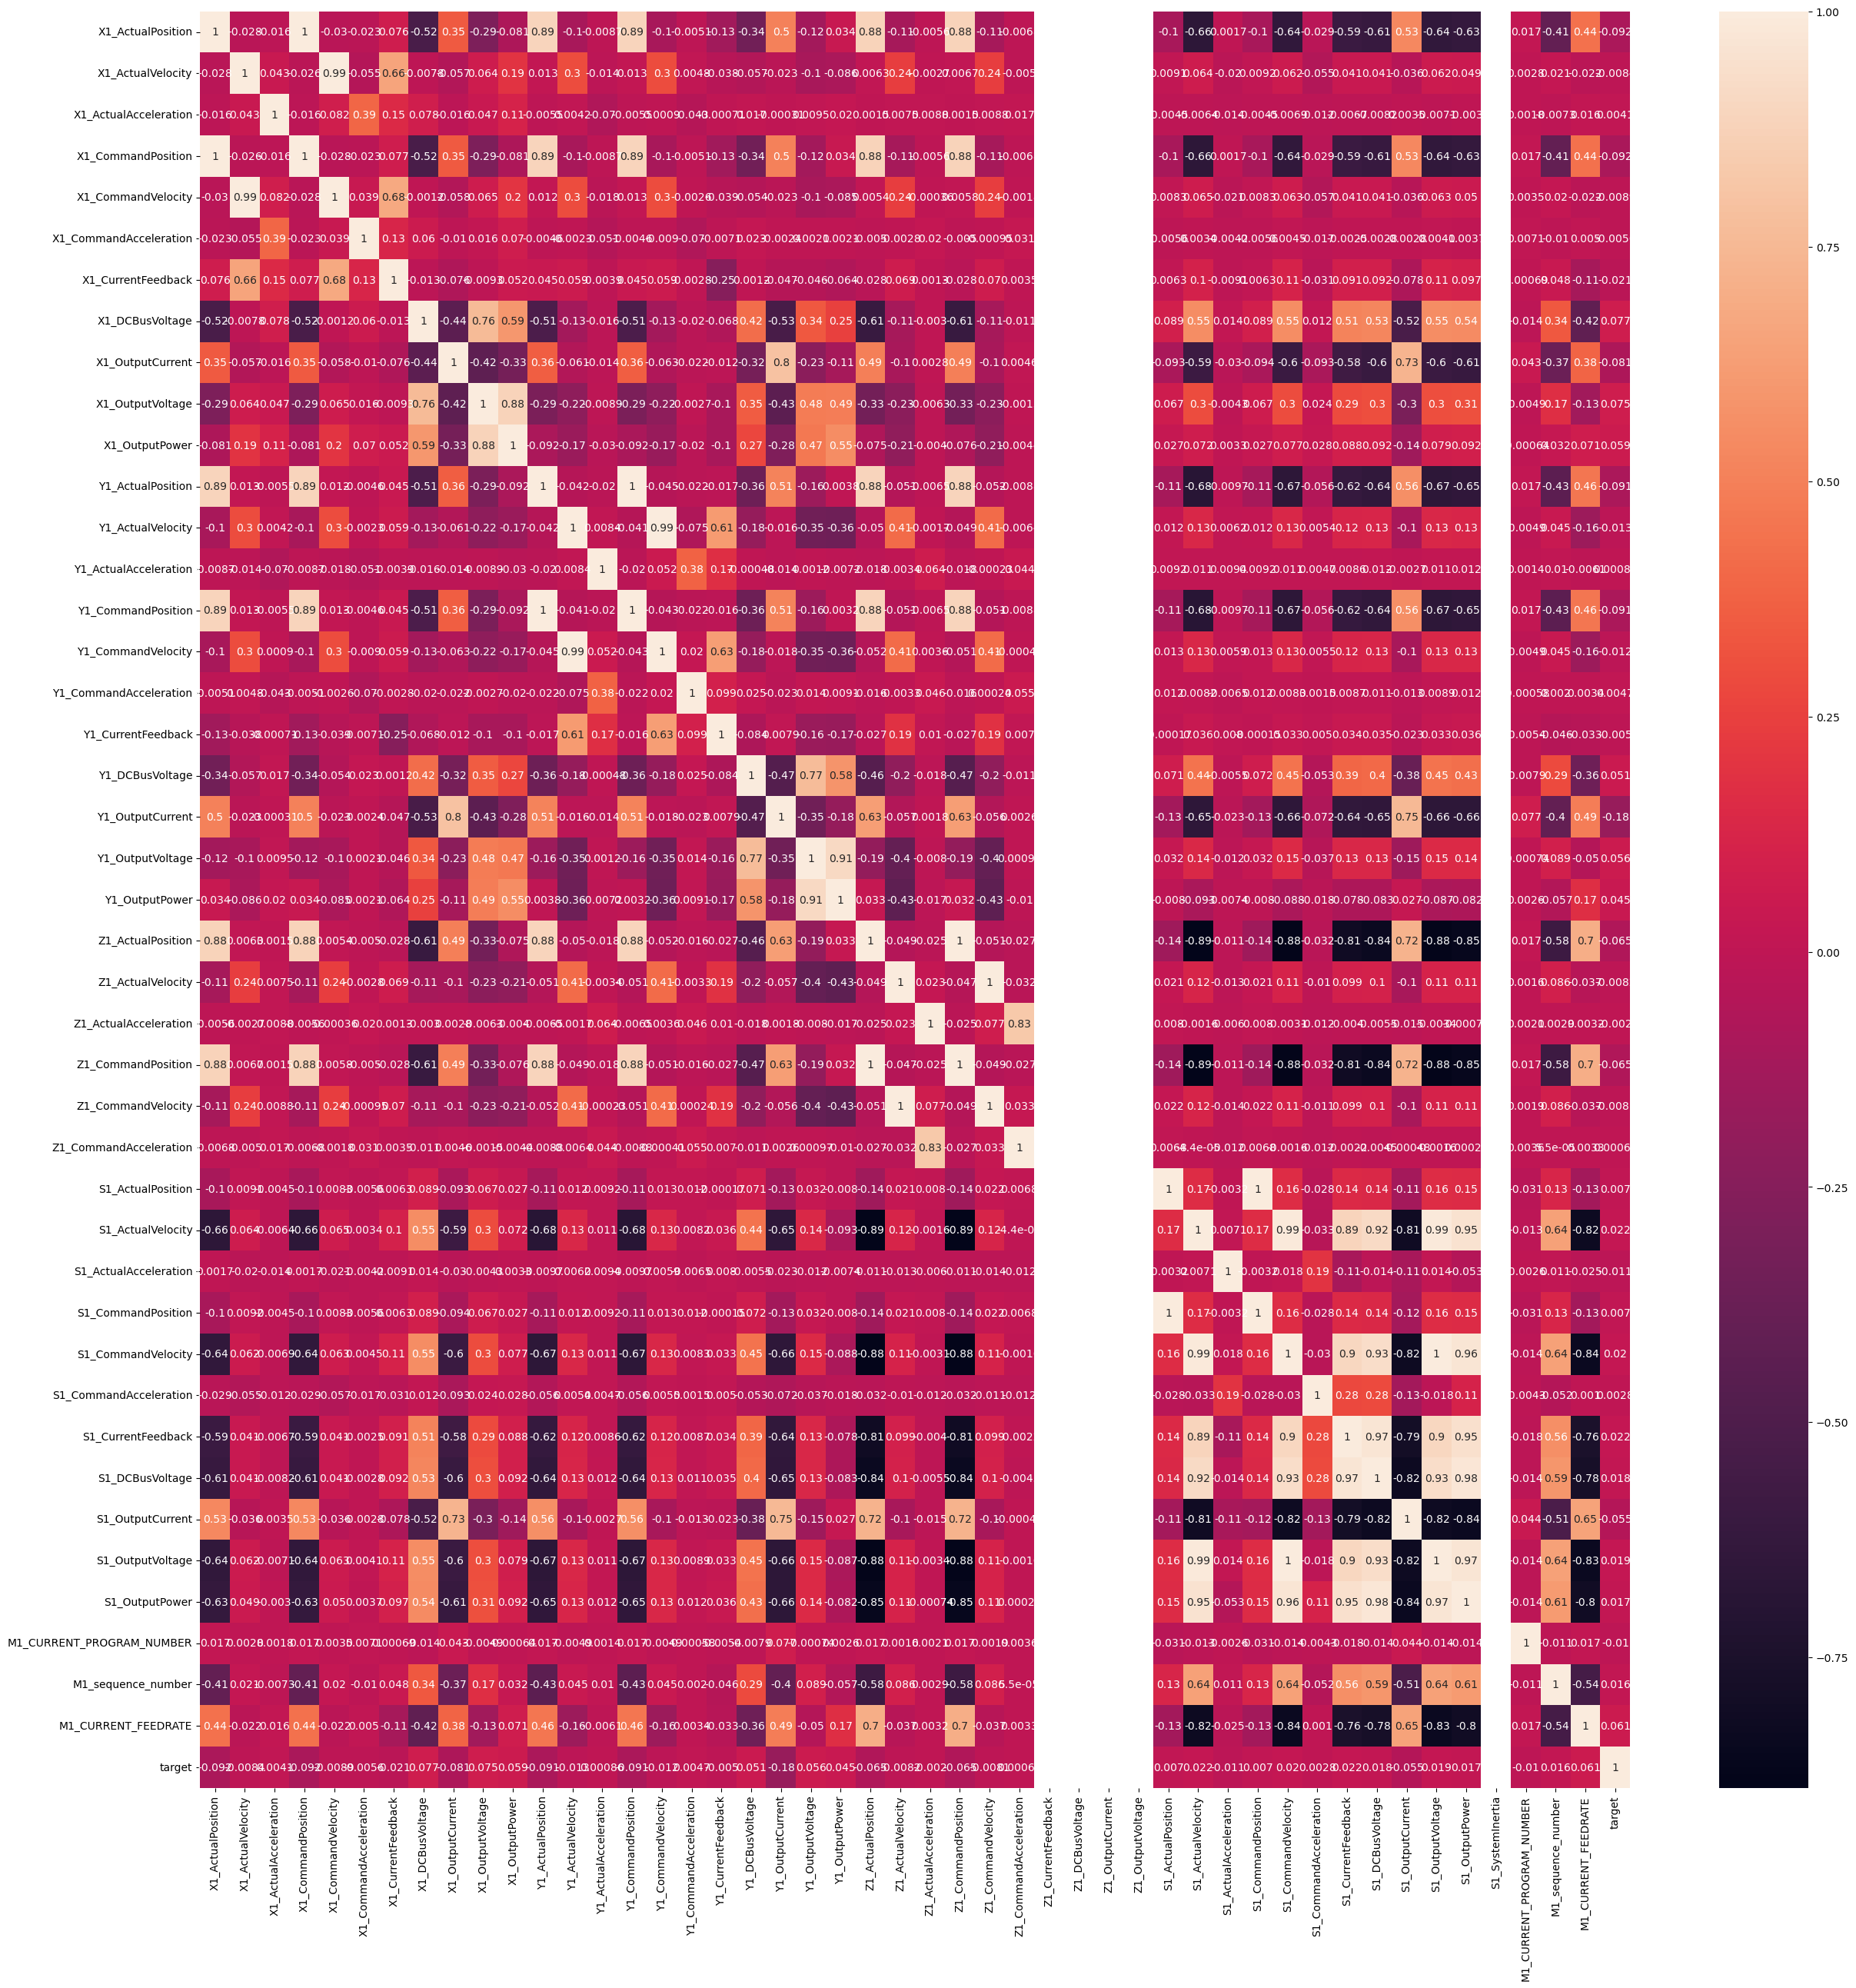

In [14]:
#visualizing correlated matrix
plt.figure(figsize=(30,30))
sns.heatmap(df_correlation, annot = True)

In [15]:
#since we can see NaN values lets check unique values in features
print(df['Z1_CurrentFeedback'].nunique())
print(df['Z1_DCBusVoltage'].nunique())
print(df['Z1_OutputCurrent'].nunique())
print(df['Z1_OutputVoltage'].nunique())
print(df['S1_SystemInertia'].nunique())

1
1
1
1
1


In [16]:
#which means that we can drop that features with NaN values even before drop correlated features because it
#is constant features
df.drop(columns=[
    'Z1_CurrentFeedback',
    'Z1_DCBusVoltage',
    'Z1_OutputCurrent',
    'Z1_OutputVoltage',
    'S1_SystemInertia'
], inplace= True)

##  Divide the data into training and testing

In [17]:
X = df.drop(columns= ['target'], axis= 1)
y = np.array(df['target'])

In [18]:
y.shape

(25286,)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size= 0.8, random_state= 100)
X_train.shape, X_test.shape

((20228, 43), (5058, 43))

## Implement ordinal encoder for object feature

In [20]:
ordinal_enc = OrdinalEncoder(
    encoding_method= 'ordered',
    variables= ['Machining_Process'],
)

ordinal_enc.fit(X_train, y_train)
X_train = ordinal_enc.transform(X_train)
X_test = ordinal_enc.transform(X_test)

In [21]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20228 entries, 5514 to 5640
Data columns (total 43 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   X1_ActualPosition          20228 non-null  float64
 1   X1_ActualVelocity          20228 non-null  float64
 2   X1_ActualAcceleration      20228 non-null  float64
 3   X1_CommandPosition         20228 non-null  float64
 4   X1_CommandVelocity         20228 non-null  float64
 5   X1_CommandAcceleration     20228 non-null  float64
 6   X1_CurrentFeedback         20228 non-null  float64
 7   X1_DCBusVoltage            20228 non-null  float64
 8   X1_OutputCurrent           20228 non-null  float64
 9   X1_OutputVoltage           20228 non-null  float64
 10  X1_OutputPower             20228 non-null  float64
 11  Y1_ActualPosition          20228 non-null  float64
 12  Y1_ActualVelocity          20228 non-null  float64
 13  Y1_ActualAcceleration      20228 non-null  float6

## Remove correlated features

In [22]:
sel = DropCorrelatedFeatures(
    threshold= 0.8,
    method= 'pearson',
    missing_values='ignore'
)

sel.fit(X_train)

DropCorrelatedFeatures()

In [23]:
sel.features_to_drop_ #features to drop

{'M1_CURRENT_FEEDRATE',
 'S1_CommandPosition',
 'S1_CommandVelocity',
 'S1_CurrentFeedback',
 'S1_DCBusVoltage',
 'S1_OutputCurrent',
 'S1_OutputPower',
 'S1_OutputVoltage',
 'X1_CommandPosition',
 'X1_CommandVelocity',
 'X1_OutputPower',
 'Y1_ActualPosition',
 'Y1_CommandPosition',
 'Y1_CommandVelocity',
 'Y1_OutputPower',
 'Z1_ActualPosition',
 'Z1_CommandAcceleration',
 'Z1_CommandPosition',
 'Z1_CommandVelocity'}

In [24]:
X_train = sel.transform(X_train)
X_test = sel.transform(X_test)

X_train.shape, X_test.shape #checking reduced size after removing correlated features

((20228, 24), (5058, 24))

In [25]:
# model functions
def run_DecisionTreeClassifier(X_train, X_test, y_train, y_test):
    name_of_the_model = 'Decision tree'
    classifier = DecisionTreeClassifier(criterion= 'entropy', random_state= 0)
    classifier.fit(X_train, y_train)
    
    metrics_of_predicted_models(X_train, X_test, y_train, y_test,classifier,name_of_the_model)
   
    parameters = {
              'max_depth' : [2,4,6,8,10,12],
              'criterion' :['gini', 'entropy','log_loss']
             }
    
    grid_search_best_parameters(classifier, parameters,X_train, y_train,name_of_the_model)

    
def run_RandomForestClassifier(X_train, X_test, y_train, y_test):
    name_of_the_model = 'Random forest'
    classifier = RandomForestClassifier(n_estimators= 10, 
                                    criterion= 'entropy', 
                                    random_state=0
                                       )

    classifier.fit(X_train, y_train)

    metrics_of_predicted_models(X_train, X_test, y_train, y_test,classifier,name_of_the_model)
    
    parameters =   {
        'n_estimators': [200, 500],
        'max_depth' : [4,5,6,7,8],
        'criterion' :['gini', 'entropy', 'log_loss']
     }
    
    grid_search_best_parameters(classifier, parameters,X_train, y_train,name_of_the_model)
    
def run_AdaBoostClassifier(X_train, X_test, y_train, y_test):
    name_of_the_model = 'Ada boost'
    classifier = AdaBoostClassifier(
        n_estimators=100, 
        learning_rate= 1.0,
        algorithm="SAMME", 
        random_state=0)

    classifier.fit(X_train, y_train)

    metrics_of_predicted_models(X_train, X_test, y_train, y_test,classifier,name_of_the_model)
    
    parameters = {
        'learning_rate':  [0.5,1.0,1.5,2.0],
        'n_estimators': [10,50,100,300,500]
             }
    grid_search_best_parameters(classifier, parameters,X_train, y_train,name_of_the_model)

def run_GradientBoostingClassifier(X_train, X_test, y_train, y_test):
    name_of_the_model = 'Gradient boosting'
    classifier = GradientBoostingClassifier(n_estimators= 10, 
                                    criterion= 'squared_error', 
                                    random_state=0
                                       )

    classifier.fit(X_train, y_train)

    metrics_of_predicted_models(X_train, X_test, y_train, y_test,classifier,name_of_the_model)
        
    parameters =   {
        "loss":["log_loss"],
        "learning_rate": [0.01, 0.025, 0.05, 0.075, 0.1, 0.15, 0.2],
        "min_samples_split": np.linspace(0.1, 0.5, 12),
        "min_samples_leaf": np.linspace(0.1, 0.5, 12),
        "max_depth":[3,5,8],
        "max_features":["log2","sqrt"],
        "criterion": ["friedman_mse",  "mae"],
        "subsample":[0.5, 0.618, 0.8, 0.85, 0.9, 0.95, 1.0]
    }
    

    grid_search_best_parameters(classifier, parameters,X_train, y_train,name_of_the_model)

def run_SVC(X_train, X_test, y_train, y_test):
    name_of_the_model = 'SVC'
    classifier = SVC(kernel= 'linear', random_state = 0, probability= True)
    classifier.fit(X_train, y_train)

    metrics_of_predicted_models(X_train, X_test, y_train, y_test,classifier,name_of_the_model)
    
    parameters = {
         'C': [0.25, 0.5, 0.75, 1],
         'kernel': ['linear', 'rbf'],
        'gamma':[0.1,0.2,0.3]
    }
    
    grid_search_best_parameters(classifier, parameters,X_train, y_train,name_of_the_model)
    
    
def run_Gaussian(X_train, X_test, y_train, y_test):
    name_of_the_model = 'Gaussian'
    classifier = GaussianNB()
    classifier.fit(X_train, y_train)
    
    metrics_of_predicted_models(X_train, X_test, y_train, y_test,classifier,name_of_the_model)
    
    
    parameters = {
        'var_smoothing': [0.00000001, 0.000000001, 0.00000001]
    }

    grid_search_best_parameters(classifier, parameters,X_train, y_train, name_of_the_model)
    
    
def run_XGboost(X_train, X_test, y_train, y_test):
    name_of_the_model = 'XG Boost'
    classifier = XGBClassifier()
    classifier.fit(X_train, y_train)

    metrics_of_predicted_models(X_train, X_test, y_train, y_test,classifier,name_of_the_model)
    
    parameters = {
        'min_child_weight': [1, 5, 10],
        'gamma': [0.5, 1, 1.5],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'max_depth': [3, 4, 5]
        }

    grid_search_best_parameters(classifier, parameters,X_train, y_train, name_of_the_model)

Ada boost
Train set
Classification report train set
              precision    recall  f1-score   support

           0       0.70      0.54      0.61      9559
           1       0.66      0.80      0.72     10669

    accuracy                           0.67     20228
   macro avg       0.68      0.67      0.67     20228
weighted avg       0.68      0.67      0.67     20228


r2 squared error train set: -0.30509661075453964
explained variance score train set: -0.2567718433728827
mean absolute error train set: 0.3252916749060708
mean squared error  train set: 0.3252916749060708
roc-auc score: 0.667685251388658

Confusion matrix train set


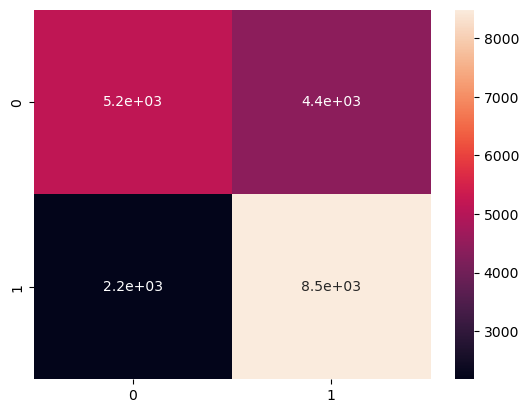

Ada boost train roc-auc with predict_proba: 0.744433000819307

Test set
Classification report test set
              precision    recall  f1-score   support

           0       0.70      0.54      0.61      2419
           1       0.65      0.79      0.72      2639

    accuracy                           0.67      5058
   macro avg       0.68      0.67      0.66      5058
weighted avg       0.68      0.67      0.67      5058


r2 squared error test set: -0.3184294287628524
explained variance score test set: -0.2682463151308925
mean absolute error test set: 0.32898378805852113
mean squared error test set: 0.32898378805852113
roc-auc score: 0.6655161918379834

Confusion matrix test set


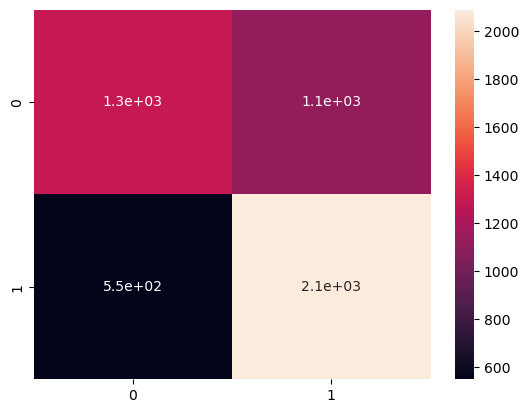

Ada boost test roc-auc with predict_proba: 0.7470917914746228

Best accuracy: 71.717465 %
Best parameters:  {'learning_rate': 1.5, 'n_estimators': 500}



In [26]:
#training the models
run_AdaBoostClassifier(X_train, X_test, y_train, y_test)

Decision tree
Train set
Classification report train set
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9559
           1       1.00      1.00      1.00     10669

    accuracy                           1.00     20228
   macro avg       1.00      1.00      1.00     20228
weighted avg       1.00      1.00      1.00     20228


r2 squared error train set: 1.0
explained variance score train set: 1.0
mean absolute error train set: 0.0
mean squared error  train set: 0.0
roc-auc score: 1.0

Confusion matrix train set


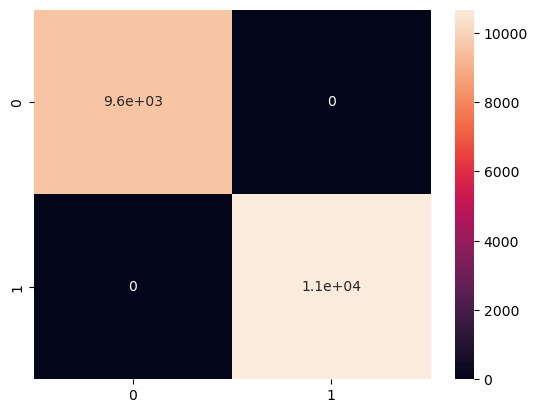

Decision tree train roc-auc with predict_proba: 1.0

Test set
Classification report test set
              precision    recall  f1-score   support

           0       0.87      0.86      0.86      2419
           1       0.87      0.88      0.88      2639

    accuracy                           0.87      5058
   macro avg       0.87      0.87      0.87      5058
weighted avg       0.87      0.87      0.87      5058


r2 squared error test set: 0.480234552122337
explained variance score test set: 0.4802652551223491
mean absolute error test set: 0.12969553183076316
mean squared error test set: 0.12969553183076316
roc-auc score: 0.8699380191019654

Confusion matrix test set


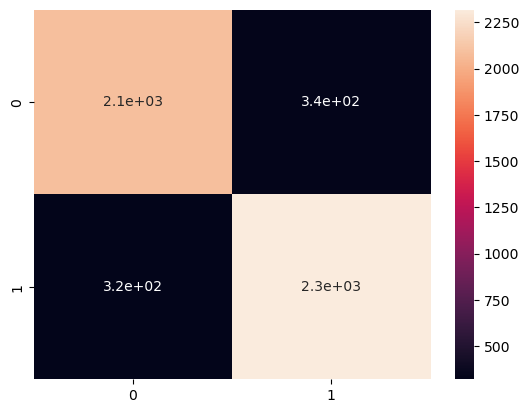

Decision tree test roc-auc with predict_proba: 0.8699380191019654

Best accuracy: 78.964781 %
Best parameters:  {'criterion': 'entropy', 'max_depth': 12}

Gaussian
Train set
Classification report train set
              precision    recall  f1-score   support

           0       0.59      0.22      0.31      9559
           1       0.55      0.86      0.67     10669

    accuracy                           0.56     20228
   macro avg       0.57      0.54      0.49     20228
weighted avg       0.57      0.56      0.50     20228


r2 squared error train set: -0.7767561457658305
explained variance score train set: -0.41856674156430396
mean absolute error train set: 0.4428514929800277
mean squared error  train set: 0.4428514929800277
roc-auc score: 0.5393653051095146

Confusion matrix train set


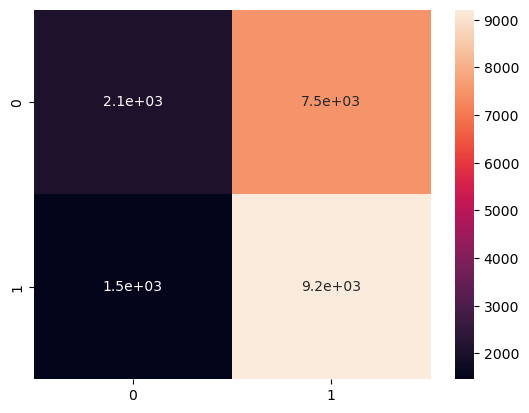

Gaussian train roc-auc with predict_proba: 0.5733172047477466

Test set
Classification report test set
              precision    recall  f1-score   support

           0       0.57      0.21      0.31      2419
           1       0.54      0.86      0.66      2639

    accuracy                           0.55      5058
   macro avg       0.56      0.53      0.49      5058
weighted avg       0.56      0.55      0.49      5058


r2 squared error test set: -0.8168020914382335
explained variance score test set: -0.45058406974844356
mean absolute error test set: 0.45334124159746936
mean squared error test set: 0.45334124159746936
roc-auc score: 0.5326261670077154

Confusion matrix test set


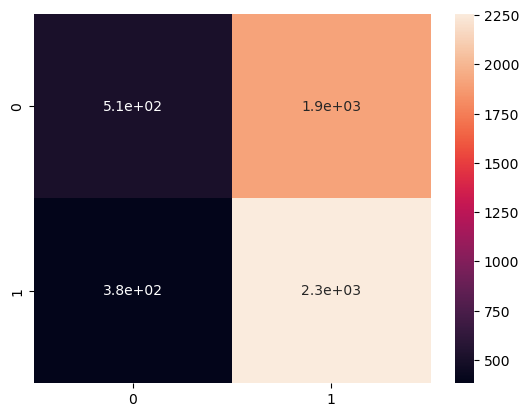

Gaussian test roc-auc with predict_proba: 0.5745263631466251

Best accuracy: 55.714875 %
Best parameters:  {'var_smoothing': 1e-09}



In [30]:
#training the models
run_DecisionTreeClassifier(X_train, X_test, y_train, y_test)
run_Gaussian(X_train, X_test, y_train, y_test)


Random forest
Train set
Classification report train set
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      9559
           1       1.00      0.99      1.00     10669

    accuracy                           1.00     20228
   macro avg       1.00      1.00      1.00     20228
weighted avg       1.00      1.00      1.00     20228


r2 squared error train set: 0.983735878103059
explained variance score train set: 0.9837485858578123
mean absolute error train set: 0.004053786830136444
mean squared error  train set: 0.004053786830136444
roc-auc score: 0.9960319251353222

Confusion matrix train set


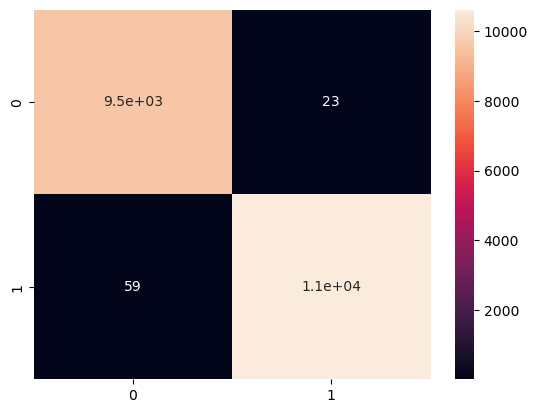

Random forest train roc-auc with predict_proba: 0.9998918958362992

Test set
Classification report test set
              precision    recall  f1-score   support

           0       0.83      0.88      0.85      2419
           1       0.89      0.83      0.86      2639

    accuracy                           0.86      5058
   macro avg       0.86      0.86      0.86      5058
weighted avg       0.86      0.86      0.86      5058


r2 squared error test set: 0.425564101049839
explained variance score test set: 0.42962457280143407
mean absolute error test set: 0.14333728746540134
mean squared error test set: 0.14333728746540134
roc-auc score: 0.8577781429415761

Confusion matrix test set


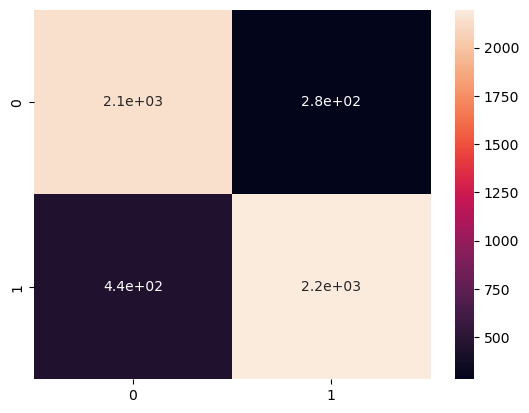

Random forest test roc-auc with predict_proba: 0.9356873970920813

Best accuracy: 76.211185 %
Best parameters:  {'criterion': 'gini', 'max_depth': 8, 'n_estimators': 500}

XG Boost
Train set
Classification report train set
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      9559
           1       0.98      0.98      0.98     10669

    accuracy                           0.98     20228
   macro avg       0.98      0.98      0.98     20228
weighted avg       0.98      0.98      0.98     20228


r2 squared error train set: 0.9063821276176075
explained variance score train set: 0.9063978162037228
mean absolute error train set: 0.023333992485663438
mean squared error  train set: 0.023333992485663438
roc-auc score: 0.9767043714705768

Confusion matrix train set


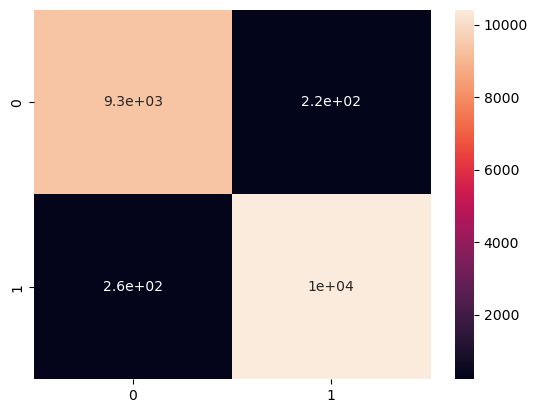

XG Boost train roc-auc with predict_proba: 0.9976851246052715

Test set
Classification report test set
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      2419
           1       0.92      0.92      0.92      2639

    accuracy                           0.92      5058
   macro avg       0.92      0.92      0.92      5058
weighted avg       0.92      0.92      0.92      5058


r2 squared error test set: 0.6616770636528018
explained variance score test set: 0.6616897521375007
mean absolute error test set: 0.08442071965203637
mean squared error test set: 0.08442071965203637
roc-auc score: 0.915341725173374

Confusion matrix test set


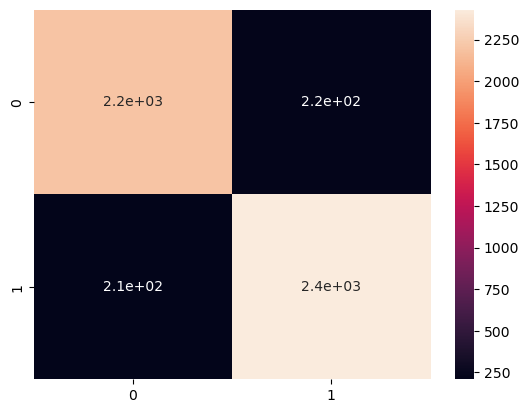

XG Boost test roc-auc with predict_proba: 0.9749916232503792

Best accuracy: 89.039982 %
Best parameters:  {'colsample_bytree': 1.0, 'gamma': 1, 'max_depth': 5, 'min_child_weight': 1, 'subsample': 1.0}



In [31]:
#training the models
run_RandomForestClassifier(X_train, X_test, y_train, y_test)
run_XGboost(X_train, X_test, y_train, y_test)

Gradient boosting
Train set
Classification report train set
              precision    recall  f1-score   support

           0       0.75      0.32      0.45      9559
           1       0.60      0.91      0.72     10669

    accuracy                           0.63     20228
   macro avg       0.68      0.61      0.59     20228
weighted avg       0.67      0.63      0.59     20228


r2 squared error train set: -0.48737378177025725
explained variance score train set: -0.1917313875590554
mean absolute error train set: 0.37072374925845364
mean squared error  train set: 0.37072374925845364
roc-auc score: 0.613215603110776

Confusion matrix train set


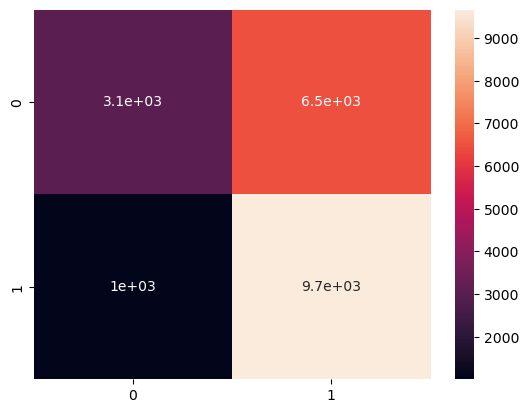

Gradient boosting train roc-auc with predict_proba: 0.6790504602879183

Test set
Classification report test set
              precision    recall  f1-score   support

           0       0.74      0.32      0.45      2419
           1       0.59      0.90      0.71      2639

    accuracy                           0.62      5058
   macro avg       0.67      0.61      0.58      5058
weighted avg       0.66      0.62      0.59      5058


r2 squared error test set: -0.513341471716976
explained variance score test set: -0.2236054062970283
mean absolute error test set: 0.3776196124950573
mean squared error test set: 0.3776196124950573
roc-auc score: 0.609947364719214

Confusion matrix test set


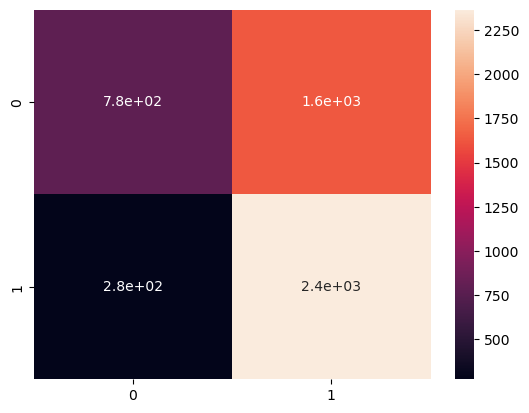

Gradient boosting test roc-auc with predict_proba: 0.6758348278854045



In [ ]:
#training the models
run_GradientBoostingClassifier(X_train, X_test, y_train, y_test) #laptop dies here

In [ ]:
#run_SVC(X_train, X_test, y_train, y_test) #this thing doesnt want to work

## Comparing results of models training

In [32]:
data = [
    train_roc_auc,
    test_roc_auc,
    best_accuracy_with_best_parameters
]

results = pd.DataFrame(data)
results

,Ada boost,Decision tree,Gaussian,Random forest,XG Boost
0,0.744433,1.000000,0.573317,0.999892,0.997685
1,0.747092,0.869938,0.574526,0.935687,0.974992
2,71.717465,78.964781,55.714875,76.211185,89.039982


## Final pipeline

In [27]:
final_pipeline = Pipeline(steps= [
    ('encoder', OrdinalEncoder(
    encoding_method= 'ordered',
    variables= ['Machining_Process'],
)),
    ('dropping_correlated_features',DropCorrelatedFeatures(
        threshold= 0.8,
        method= 'pearson',
        missing_values='ignore')),
    ('training_best_model', AdaBoostClassifier(
        n_estimators=500, 
        learning_rate= 1.5,
        algorithm="SAMME", 
        random_state=0))
])